In [1]:
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import matplotlib

import matplotlib.ticker as ticker

import numpy as np

from menedpy.domain import Domain
from menedpy.mesh import generate_mesh
from menedpy.problem import Problem

from menedpy import solve

In [2]:
plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.size': 16,
    'axes.grid': True, 
    'xtick.top': True,
    'ytick.right': True,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'grid.alpha': 0.6
})

In [3]:
from menedpy.time_stepping import explicit_euler_step, implicit_euler_step, crank_nicolson_step
from menedpy.systems import newton, KLAM, super_ostrowski

all_sols = {}

domain = Domain()
mesh = generate_mesh(domain=domain, nx=10, ny=10)
problem = Problem(domain=domain, final_time=0.1)


for time_stepper, time_stepper_name in zip(
    [explicit_euler_step, implicit_euler_step, crank_nicolson_step],
    ["explicit_euler", "implicit_euler", "crank_nicolson"]
):
    for nonlinear_solver, nonlinear_solver_name in zip(
        [newton, KLAM, super_ostrowski],
        ["newton", "KLAM", "super_ostrowski"]
    ):
        times, solutions, info = solve(
            problem=problem,
            mesh=mesh, 
            n_steps=1000,
            time_stepper=time_stepper,
            nonlinear_solver=nonlinear_solver,
            return_info=True
        ) 

        print(time_stepper_name, nonlinear_solver_name)

        all_sols.update({(time_stepper_name, nonlinear_solver_name): (times, solutions, info)})    

explicit_euler newton
explicit_euler KLAM
explicit_euler super_ostrowski
implicit_euler newton
implicit_euler KLAM
implicit_euler super_ostrowski
crank_nicolson newton
crank_nicolson KLAM
crank_nicolson super_ostrowski


In [12]:
np.save("precomputed_solutions.npy", all_sols)
sols = np.load("precomputed_solutions.npy", allow_pickle=True).item()

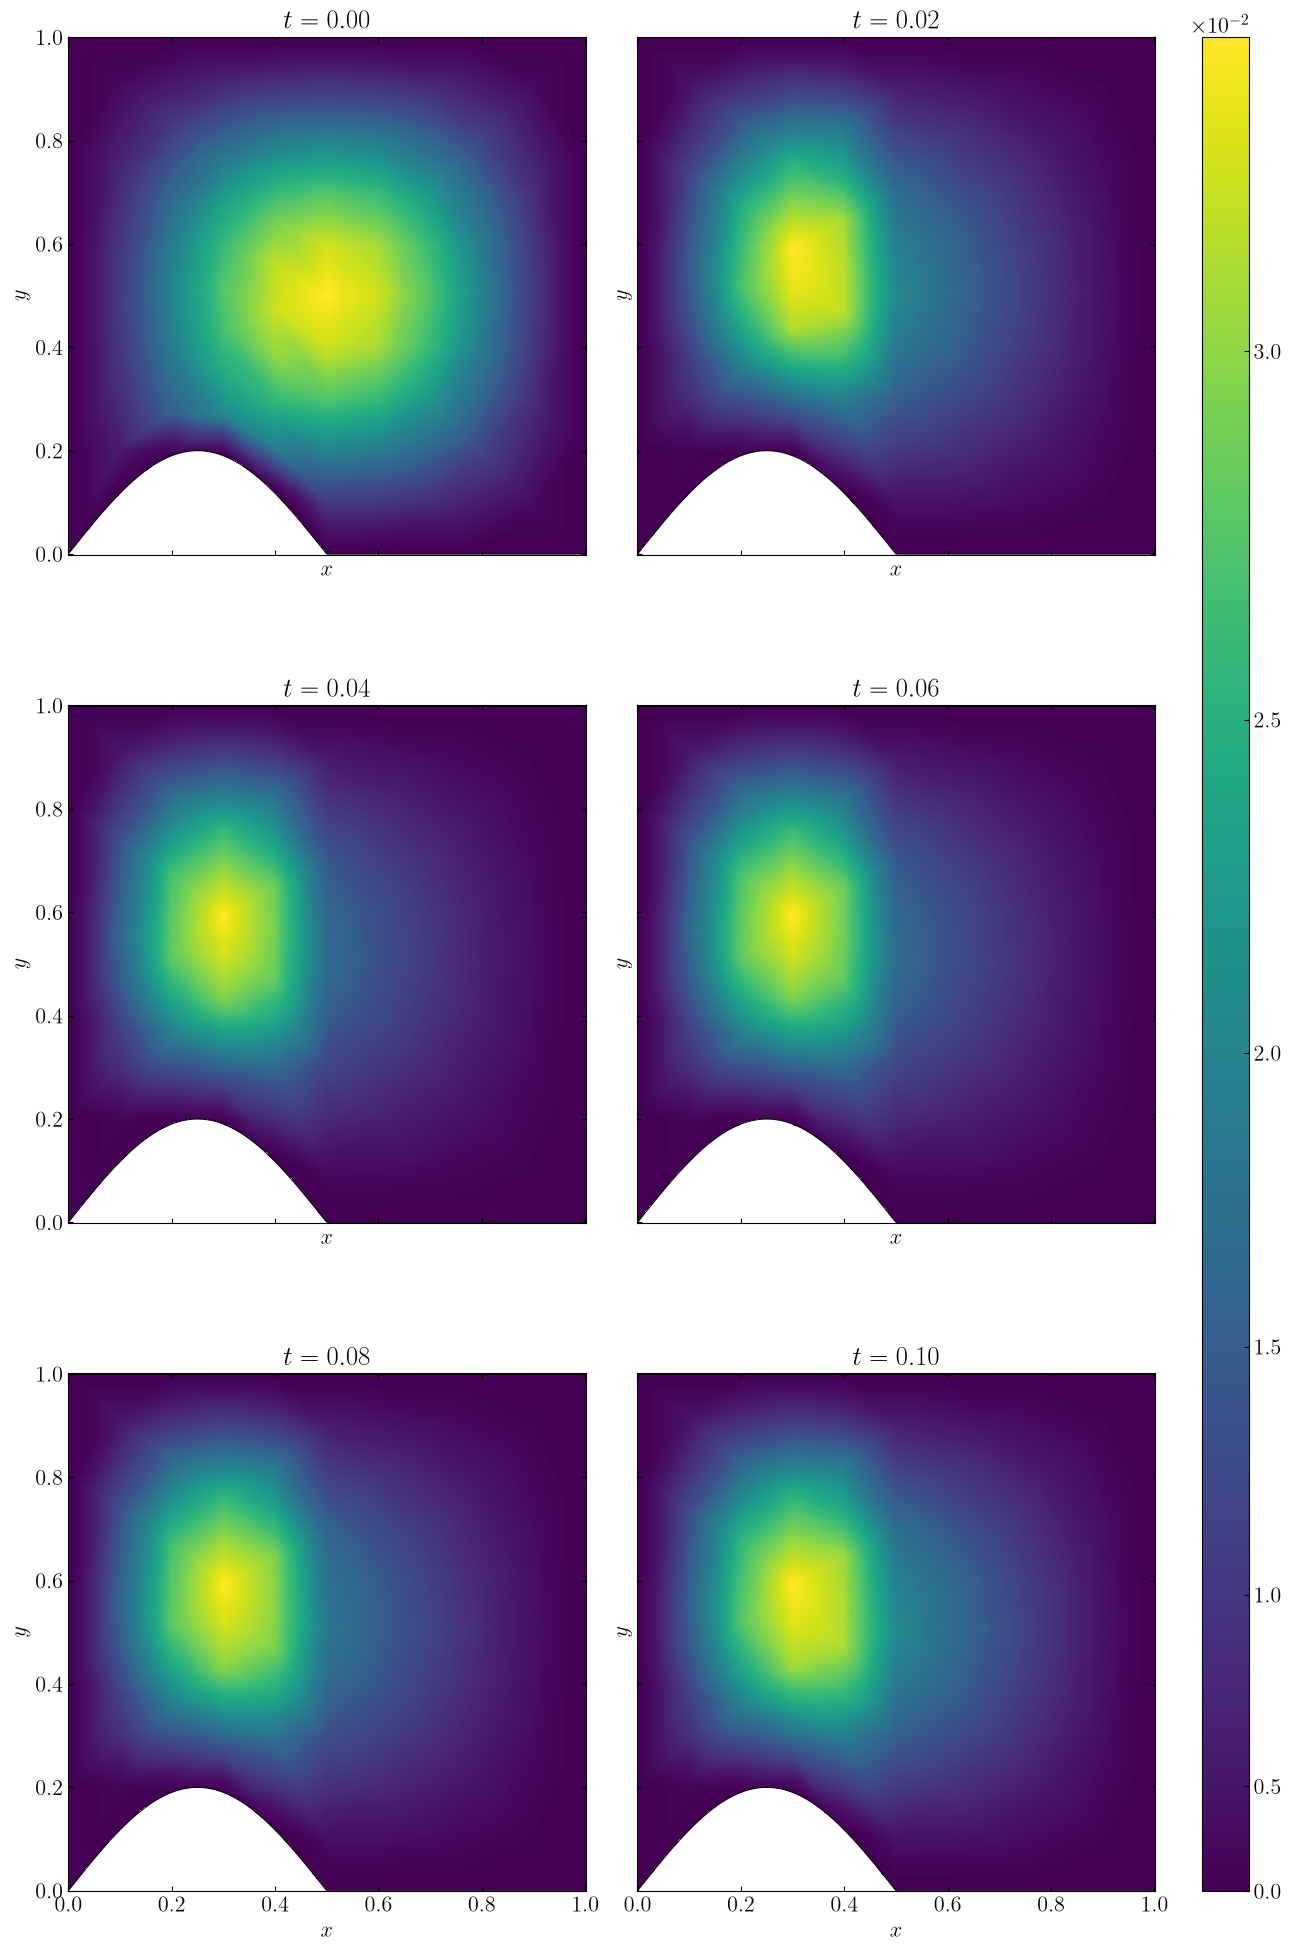

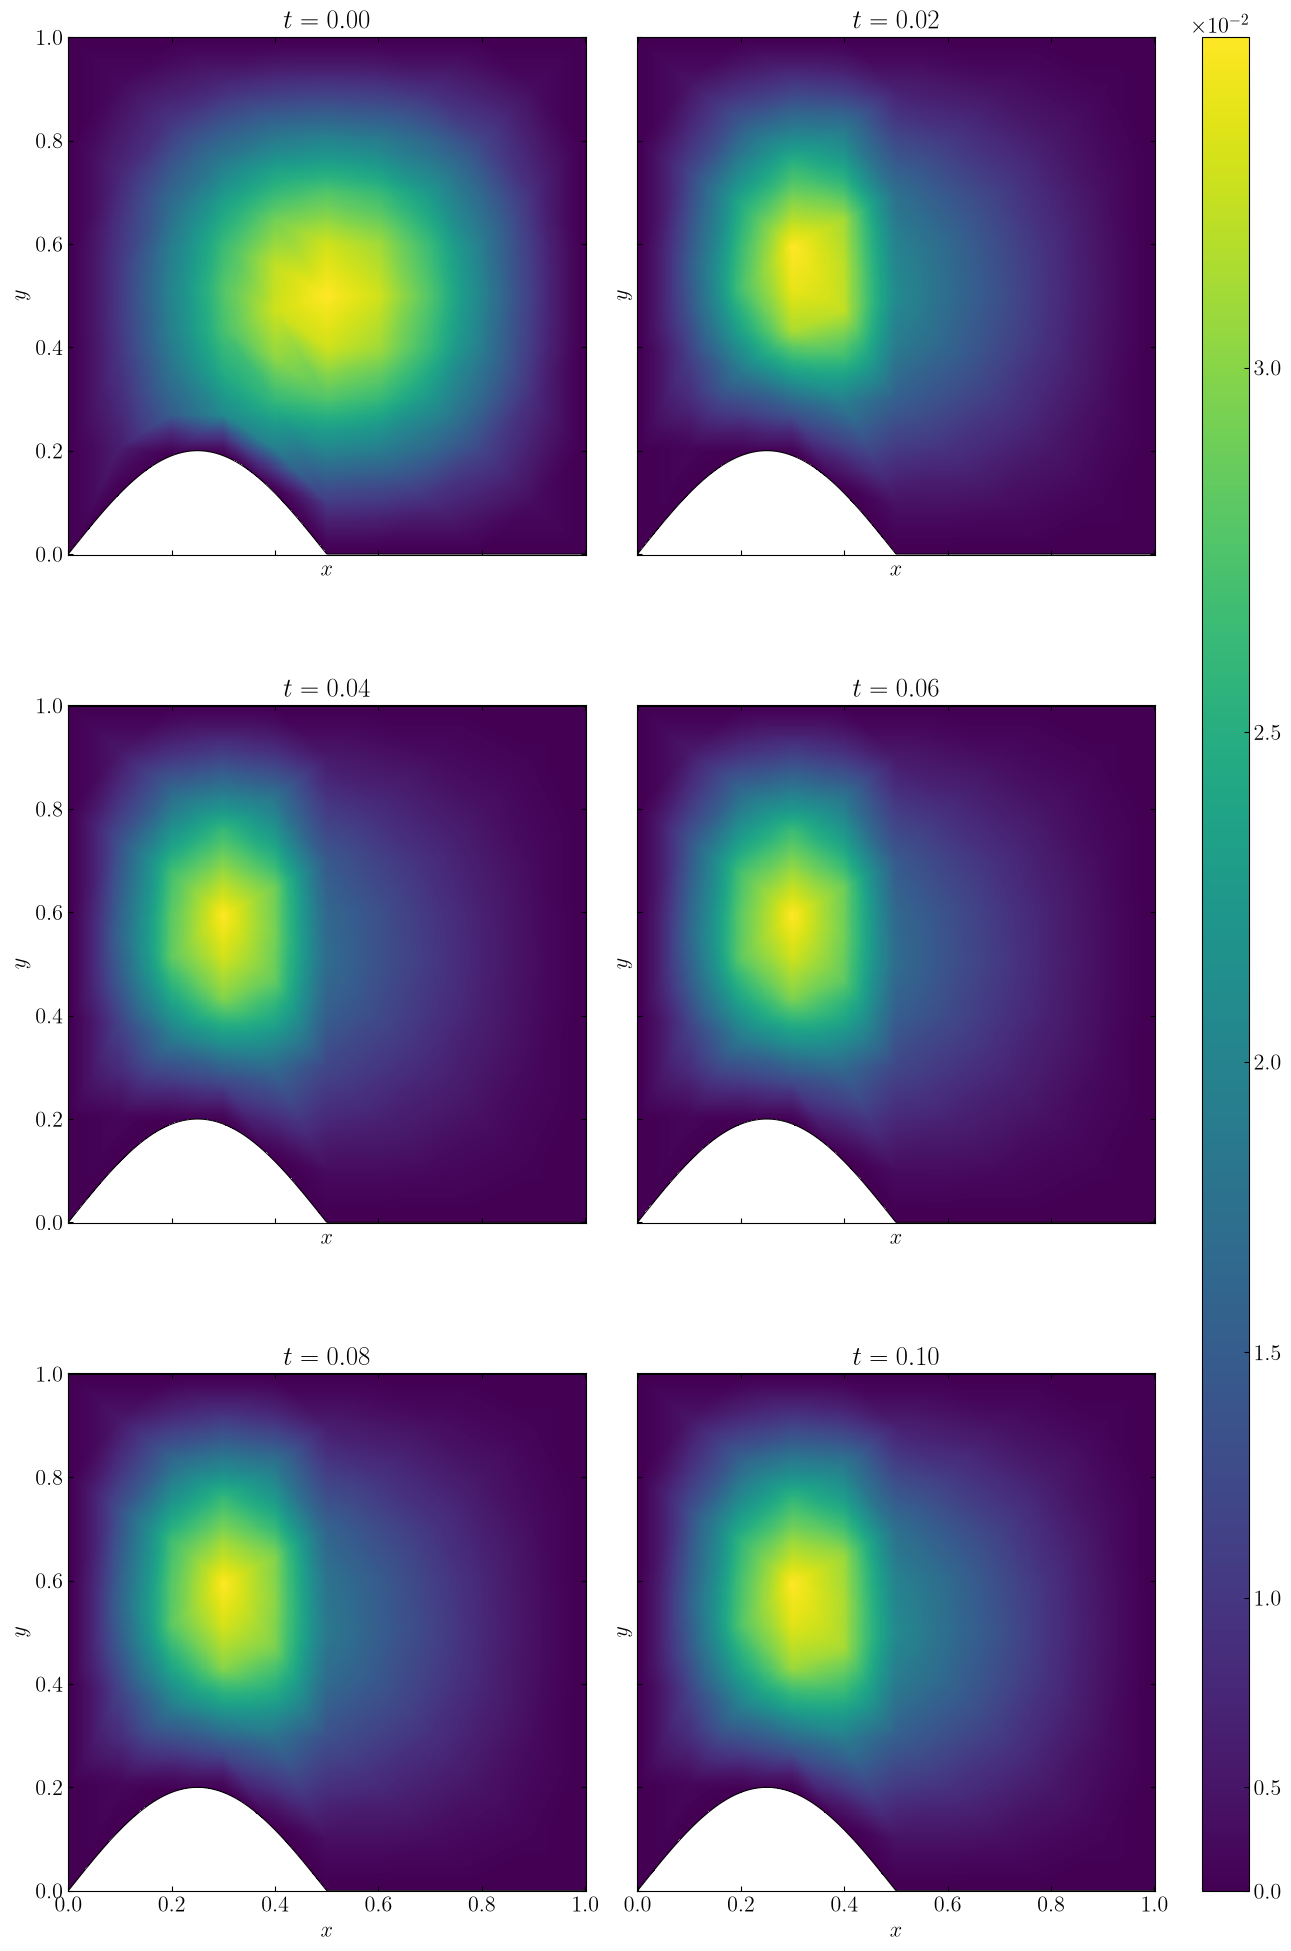

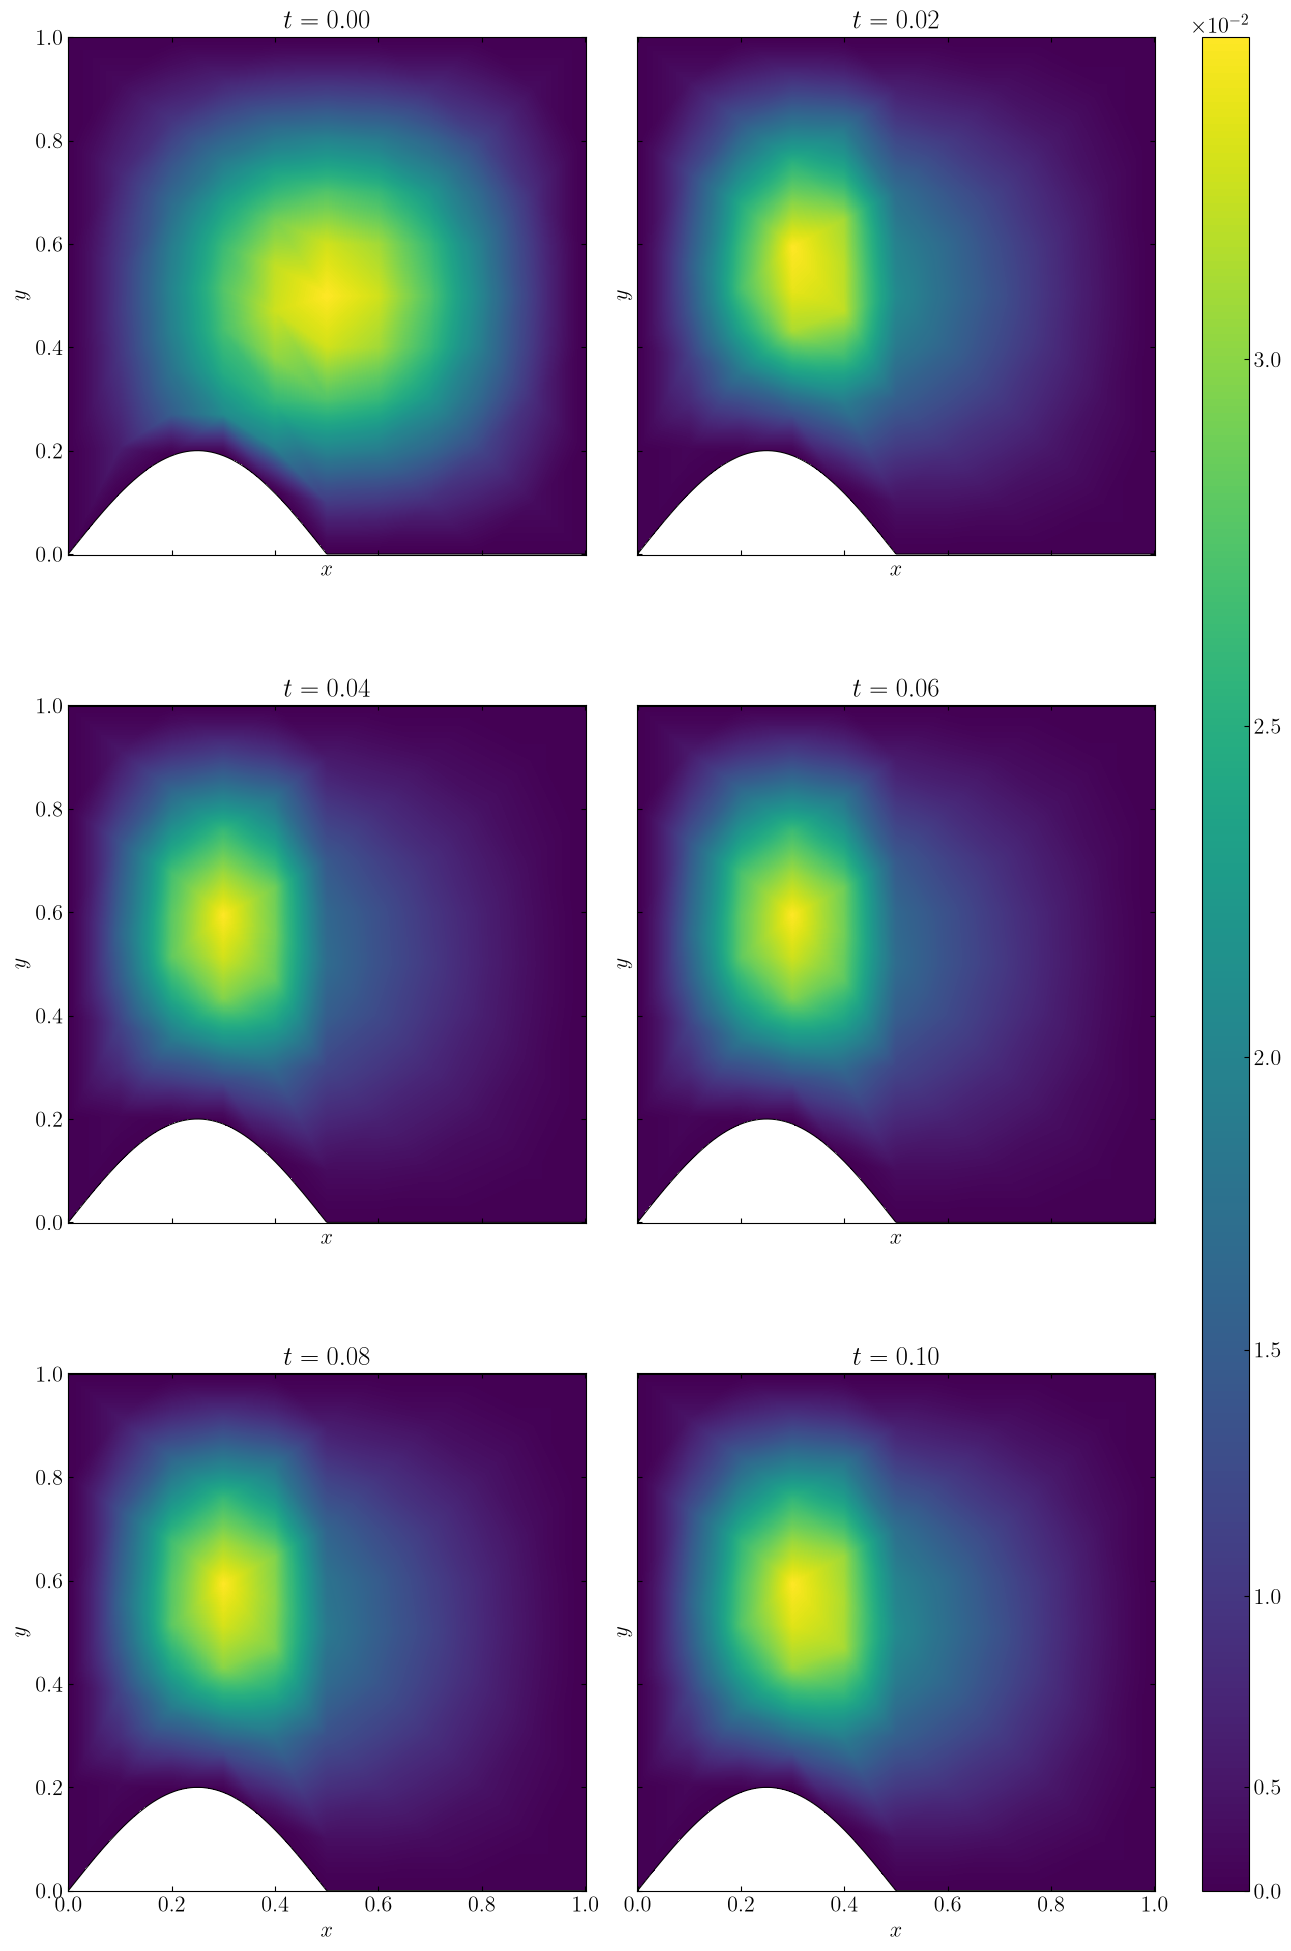

In [ ]:
n = 500
x = np.linspace(*domain.x_range, n)
y = np.linspace(*domain.x_range, n)
X, Y = np.meshgrid(x, y)

# Region Ω:
mask = (Y > np.vectorize(domain.lower_boundary)(X)) * (Y < np.vectorize(domain.upper_boundary)(X))

for time_stepper, name in zip(
    [explicit_euler_step, implicit_euler_step, crank_nicolson_step],
    ["explicit_euler", "implicit_euler", "crank_nicolson"]
):

    times, solutions, _ = sols[name, "super_ostrowski"]


    n = 500
    x = np.linspace(0, 1, n)
    y = np.linspace(0, 1, n)
    X, Y = np.meshgrid(x, y)

    upper = np.vectorize(domain.upper_boundary)(x)
    lower = np.vectorize(domain.lower_boundary)(x)

    FIG, AX = plt.subplots(3,2, figsize=(6.4*2,20), sharex=True, sharey=True, constrained_layout=True)

    for i, ax in zip(np.linspace(0, len(solutions)-1, 6), AX.flatten()):

        i = int(i)

        triangulation = mtri.Triangulation(mesh.points[:, 0], mesh.points[:, 1], mesh.triangles)
        interpolator = mtri.LinearTriInterpolator(triangulation, solutions[i])
        U = np.ma.filled(interpolator(X, Y), np.nan)
        U_masked = np.where(mask, U, np.nan)

        im = ax.pcolormesh(
            X, Y, U_masked,
            cmap="viridis",
            rasterized=True,
            norm=matplotlib.colors.PowerNorm(gamma=1.5)
        )

        ax.set_title(f"$t={times[i]:.2f}$")
        ax.grid(False)
        
        ax.plot(x, upper, 'k', linewidth=0.75)
        ax.plot(x, lower, 'k', linewidth=0.75)
        
        ax.set_aspect("equal")

        ax.set_xlabel("$x$")
        ax.set_ylabel("$y$")

    plt.xticks(np.arange(0, 1.1, 0.2))

    cbar = FIG.colorbar(
        im,
        ax=AX,              # or ax=AX.ravel()
        location="right",
        shrink=0.931,
        pad=0.02,
        aspect=40,
    )

    formatter = ticker.ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((-2, -2))  # Force ×10^-2
    cbar.formatter = formatter
    cbar.update_ticks()

    plt.savefig(f"solucion_{name}.pdf", dpi=300)
    plt.show()

# Tabla: comparación todo con todo

In [14]:
def printn(n):
    return f"{n:.2e}".replace("e", "\\times 10^{") + "}"

In [15]:
sols = np.load("precomputed_solutions.npy", allow_pickle=True).item()

In [16]:
_, reference_sol, _ = sols["crank_nicolson", "super_ostrowski"]

for time_stepper, time_stepper_name in zip(
    [explicit_euler_step, implicit_euler_step, crank_nicolson_step],
    ["explicit_euler", "implicit_euler", "crank_nicolson"]
):
    print(r"\midrule")
    for nonlinear_solver, nonlinear_solver_name in zip(
        [newton, KLAM, super_ostrowski],
        ["newton", "KLAM", "super_ostrowski"]
    ):
        times, solutions, info = sols[time_stepper_name, nonlinear_solver_name]

        num_iterations = [i["iterations"] for i in info] 
        terminal_residuals = [i["residuals"][-1] if len(i["residuals"]) != 0 else 0.0 for i in info] 

        print(
            time_stepper_name, " & ", 
            nonlinear_solver_name, " & ",
            f"{np.mean(num_iterations):.2f}", " & $",
            printn(np.max(terminal_residuals)), "$ & $",
            printn(np.linalg.norm(reference_sol - solutions)), r"$ \\"
        )
      

        

\midrule
explicit_euler  &  newton  &  0.00  & $ 0.00\times 10^{+00} $ & $ 1.08\times 10^{-01} $ \\
explicit_euler  &  KLAM  &  0.00  & $ 0.00\times 10^{+00} $ & $ 1.08\times 10^{-01} $ \\
explicit_euler  &  super_ostrowski  &  0.00  & $ 0.00\times 10^{+00} $ & $ 1.08\times 10^{-01} $ \\
\midrule
implicit_euler  &  newton  &  1.95  & $ 9.97\times 10^{-11} $ & $ 1.05\times 10^{-01} $ \\
implicit_euler  &  KLAM  &  1.00  & $ 2.11\times 10^{-12} $ & $ 1.05\times 10^{-01} $ \\
implicit_euler  &  super_ostrowski  &  1.00  & $ 5.41\times 10^{-14} $ & $ 1.05\times 10^{-01} $ \\
\midrule
crank_nicolson  &  newton  &  1.87  & $ 9.93\times 10^{-11} $ & $ 5.19\times 10^{-10} $ \\
crank_nicolson  &  KLAM  &  1.00  & $ 7.19\times 10^{-13} $ & $ 4.09\times 10^{-13} $ \\
crank_nicolson  &  super_ostrowski  &  1.00  & $ 5.63\times 10^{-14} $ & $ 0.00\times 10^{+00} $ \\


In [17]:
num_iterations = [i["iterations"] for i in info] 
terminal_residuals = [i["residuals"][-1] for i in info] 
np.mean(num_iterations)

np.float64(1.0)

In [18]:
info

[{'residuals': [np.float64(2.8142785022841926e-14)],
  'errors': [np.float64(0.06270023623274254)],
  'iterations': 1,
  'nss_time': 0.06081440002890304},
 {'residuals': [np.float64(5.63416034792173e-14)],
  'errors': [np.float64(0.045885525546070914)],
  'iterations': 1,
  'nss_time': 0.06169820000650361},
 {'residuals': [np.float64(5.572921481462953e-14)],
  'errors': [np.float64(0.041934144999303716)],
  'iterations': 1,
  'nss_time': 0.06596129998797551},
 {'residuals': [np.float64(4.405221704799532e-14)],
  'errors': [np.float64(0.03981880689709278)],
  'iterations': 1,
  'nss_time': 0.06113799999002367},
 {'residuals': [np.float64(5.0282195668380897e-14)],
  'errors': [np.float64(0.038377221871615096)],
  'iterations': 1,
  'nss_time': 0.06064780004089698},
 {'residuals': [np.float64(3.76822190084106e-14)],
  'errors': [np.float64(0.03728768325077874)],
  'iterations': 1,
  'nss_time': 0.06092830002307892},
 {'residuals': [np.float64(4.3439098578223975e-14)],
  'errors': [np.floa

In [19]:
terminal_residuals

[np.float64(2.8142785022841926e-14),
 np.float64(5.63416034792173e-14),
 np.float64(5.572921481462953e-14),
 np.float64(4.405221704799532e-14),
 np.float64(5.0282195668380897e-14),
 np.float64(3.76822190084106e-14),
 np.float64(4.3439098578223975e-14),
 np.float64(4.2148721908946644e-14),
 np.float64(4.587680127395173e-14),
 np.float64(4.348447527353602e-14),
 np.float64(4.255848491649395e-14),
 np.float64(4.208316447489627e-14),
 np.float64(3.295848094936011e-14),
 np.float64(3.920077860668753e-14),
 np.float64(3.6361117655407895e-14),
 np.float64(4.2604799529085314e-14),
 np.float64(3.281455676413566e-14),
 np.float64(3.887746769535612e-14),
 np.float64(4.043894974555048e-14),
 np.float64(3.809860975949991e-14),
 np.float64(5.17892563931115e-14),
 np.float64(4.322062729257126e-14),
 np.float64(3.6230712748823524e-14),
 np.float64(4.7065076456546854e-14),
 np.float64(4.622795898851388e-14),
 np.float64(3.8928162028659456e-14),
 np.float64(4.2780337774645346e-14),
 np.float64(2.6526664

In [20]:
_,_, info = sols["crank_nicolson", "newton"]

In [21]:
terminal_residuals = [r[-1] for r in residuals]
max(terminal_residuals)

NameError: name 'residuals' is not defined

In [ ]:
info

[{'residuals': [np.float64(2.8142785022841926e-14)],
  'errors': [np.float64(0.06270023623274254)],
  'iterations': 1,
  'nss_time': 0.08026389998849481},
 {'residuals': [np.float64(5.63416034792173e-14)],
  'errors': [np.float64(0.045885525546070914)],
  'iterations': 1,
  'nss_time': 0.08362930000294},
 {'residuals': [np.float64(5.572921481462953e-14)],
  'errors': [np.float64(0.041934144999303716)],
  'iterations': 1,
  'nss_time': 0.08227419992908835},
 {'residuals': [np.float64(4.405221704799532e-14)],
  'errors': [np.float64(0.03981880689709278)],
  'iterations': 1,
  'nss_time': 0.08331070002168417},
 {'residuals': [np.float64(5.0282195668380897e-14)],
  'errors': [np.float64(0.038377221871615096)],
  'iterations': 1,
  'nss_time': 0.07933970005251467},
 {'residuals': [np.float64(3.76822190084106e-14)],
  'errors': [np.float64(0.03728768325077874)],
  'iterations': 1,
  'nss_time': 0.08311609993688762},
 {'residuals': [np.float64(4.3439098578223975e-14)],
  'errors': [np.float64

In [22]:
for time_stepper, time_stepper_name in zip(
    [explicit_euler_step, implicit_euler_step, crank_nicolson_step],
    ["explicit_euler", "implicit_euler", "crank_nicolson"]
):
    print(r"\midrule")
    for nonlinear_solver, nonlinear_solver_name in zip(
        [newton, KLAM, super_ostrowski],
        ["newton", "KLAM", "super_ostrowski"]
    ):
        times, solutions, info = sols[time_stepper_name, nonlinear_solver_name]

        num_iterations = [i["iterations"] for i in info] 
        terminal_residuals = [i["residuals"][-1] if len(i["residuals"]) != 0 else 0.0 for i in info] 

        print(
            time_stepper_name, " & ", 
            nonlinear_solver_name, " & ",
            f"{np.mean(num_iterations):.2f}", " & $",
            printn(np.max(terminal_residuals)), "$ & $",
            printn(np.linalg.norm(reference_sol - solutions)), r"$ \\"
        )

\midrule
explicit_euler  &  newton  &  0.00  & $ 0.00\times 10^{+00} $ & $ 1.08\times 10^{-01} $ \\
explicit_euler  &  KLAM  &  0.00  & $ 0.00\times 10^{+00} $ & $ 1.08\times 10^{-01} $ \\
explicit_euler  &  super_ostrowski  &  0.00  & $ 0.00\times 10^{+00} $ & $ 1.08\times 10^{-01} $ \\
\midrule
implicit_euler  &  newton  &  1.95  & $ 9.97\times 10^{-11} $ & $ 1.05\times 10^{-01} $ \\
implicit_euler  &  KLAM  &  1.00  & $ 2.11\times 10^{-12} $ & $ 1.05\times 10^{-01} $ \\
implicit_euler  &  super_ostrowski  &  1.00  & $ 5.41\times 10^{-14} $ & $ 1.05\times 10^{-01} $ \\
\midrule
crank_nicolson  &  newton  &  1.87  & $ 9.93\times 10^{-11} $ & $ 5.19\times 10^{-10} $ \\
crank_nicolson  &  KLAM  &  1.00  & $ 7.19\times 10^{-13} $ & $ 4.09\times 10^{-13} $ \\
crank_nicolson  &  super_ostrowski  &  1.00  & $ 5.63\times 10^{-14} $ & $ 0.00\times 10^{+00} $ \\


In [23]:
plt.rcParams.update({
    'font.size': 12
})

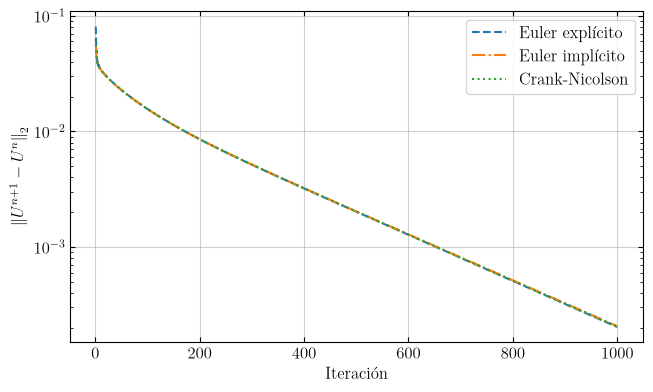

In [24]:
fig = plt.figure(figsize=(6.4,3.8))
ax=plt.subplot(1,1,1)

for time_stepper_name, plot_name, line in zip(
    ["explicit_euler", "implicit_euler", "crank_nicolson"],
    ["Euler explícito", "Euler implícito", "Crank-Nicolson"],
    ["--","-.",":"]
    ):

    times, solutions, _ = sols[time_stepper_name, "super_ostrowski"]

    difference = [np.linalg.norm(solutions[i,:] - solutions[i+1,:]) for i in range(len(times)-1)]

    ax.semilogy(range(1,len(times)), difference, line, label=plot_name)

# plt.title('Title')
plt.xlabel(r'Iteración')
plt.ylabel(r'$\left\|U^{n+1} - U^n\right\|_2$')
# plt.xlim(0, 1)
# plt.ylim(0, 1)

ax.legend()

# ax.set_aspect(250)

plt.tight_layout(pad=0.2)

plt.savefig('evolution.pdf')